Avance 4

En este notebook se realiza una optimización del umbral de decisión (threshold) del modelo supervisado con mejor desempeño para la predicción de churn.

Dado que el problema presenta clases desbalanceadas y que el costo de no detectar a un cliente que abandona el banco es elevado, se evalúan distintos valores de threshold en función de una métrica de negocio basada en costos.

El objetivo es identificar el punto de corte que minimiza el costo total y mejora la detección de clientes en riesgo, alineando el modelo con las necesidades del negocio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix


In [2]:
# 2) Carga de datos

df = pd.read_csv("Churn_Modelling (1).csv")

print("Dimensión del dataset:", df.shape)
df.head()

Dimensión del dataset: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# 4) Definición de X e y

X = df.drop(columns="Exited")
y = df["Exited"]

print("Distribución de la variable objetivo (Exited):")
print(y.value_counts())
print("\nProporción:")
print(y.value_counts(normalize=True))

Distribución de la variable objetivo (Exited):
Exited
0    7963
1    2037
Name: count, dtype: int64

Proporción:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [4]:
X.dtypes


RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
dtype: object

In [5]:
# Eliminamos columnas no informativas
drop_cols = ["RowNumber", "CustomerId", "Surname"]

X = df.drop(columns=["Exited"] + drop_cols)
y = df["Exited"]

print("Columnas finales de X:")
print(X.columns)


Columnas finales de X:
Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'],
      dtype='object')


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

cat_cols, num_cols


(['Geography', 'Gender'],
 ['CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'])

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Modelos base
xgb_model = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

cat_model = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.08,
    random_state=42,
    verbose=False,
    loss_function="Logloss"
)

# Stacking
stacking_model = StackingClassifier(
    estimators=[
        ("xgb", xgb_model),
        ("cat", cat_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    n_jobs=-1
)

# Pipeline completo (ACA VA preprocess SIN S)
best_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", stacking_model)
])

# Entrenamiento
best_model.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [10]:
y_proba = best_model.predict_proba(X_test)[:, 1]
y_proba[:5]


array([0.05772877, 0.08421812, 0.06179271, 0.06230121, 0.07315727])

In [11]:
y_true = y_test.to_numpy()


In [12]:
COST_FN = 10   # No detectar churn (muy caro)
COST_FP = 1    # Alertar churn y no era (contacto/beneficio)


In [13]:
from sklearn.metrics import confusion_matrix

def cost_for_threshold(y_true, y_proba, thr, cost_fn=10, cost_fp=1):
    y_pred = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fn * cost_fn + fp * cost_fp
    return tn, fp, fn, tp, total_cost


In [14]:
thresholds = np.linspace(0.01, 0.99, 99)

rows = []
for thr in thresholds:
    tn, fp, fn, tp, total_cost = cost_for_threshold(
        y_true, y_proba, thr, cost_fn=COST_FN, cost_fp=COST_FP
    )
    rows.append({
        "threshold": thr,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "total_cost": total_cost
    })

df_thr = pd.DataFrame(rows)

best_row = df_thr.loc[df_thr["total_cost"].idxmin()]
best_thr = float(best_row["threshold"])

best_thr, float(best_row["total_cost"])


(0.08, 1104.0)

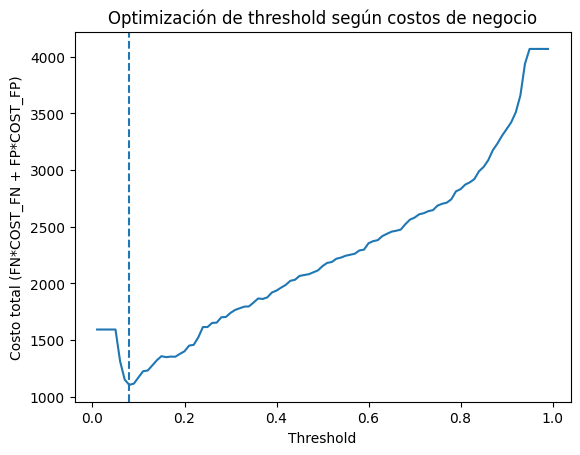

In [15]:
plt.figure()
plt.plot(df_thr["threshold"], df_thr["total_cost"])
plt.axvline(best_thr, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("Costo total (FN*COST_FN + FP*COST_FP)")
plt.title("Optimización de threshold según costos de negocio")
plt.show()


Interpretación

El gráfico muestra que el costo total se minimiza alrededor de un threshold de 0.08.

Umbrales más altos aumentan el costo por la mayor cantidad de clientes que abandonan sin ser detectados, mientras que un threshold más bajo reduce ese riesgo, aun generando más alertas falsas, lo cual es preferible para el negocio.

In [23]:
# Matriz de confusión con threshold óptimo
tn, fp, fn, tp, total_cost = cost_for_threshold(
    y_true, y_proba, best_thr, cost_fn=COST_FN, cost_fp=COST_FP
)

cm = pd.DataFrame(
    [[tn, fp],
     [fn, tp]],
    index=["Real 0 (No churn)", "Real 1 (Churn)"],
    columns=["Pred 0", "Pred 1"]
)

cm


,Pred 0,Pred 1
Real 0 (No churn),869,724
Real 1 (Churn),38,369


In [24]:
pd.Series({
    "Threshold óptimo": best_thr,
    "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    "Costo FP (FP*COST_FP)": fp*COST_FP,
    "Costo FN (FN*COST_FN)": fn*COST_FN,
    "Costo total": total_cost
})


Threshold óptimo            0.08
TN                        869.00
FP                        724.00
FN                         38.00
TP                        369.00
Costo FP (FP*COST_FP)     724.00
Costo FN (FN*COST_FN)     380.00
Costo total              1104.00
dtype: float64

Interpretación

Con un threshold de 0.08, el modelo reduce al mínimo los falsos negativos (FN = 38), logrando una alta detección de clientes que abandonan.
Aunque aumentan los falsos positivos, el costo total (1104) es menor, lo que hace que este umbral sea el más conveniente para el negocio.

In [25]:
tn05, fp05, fn05, tp05, cost05 = cost_for_threshold(
    y_true, y_proba, 0.5, cost_fn=COST_FN, cost_fp=COST_FP
)

pd.DataFrame([
    {"threshold": 0.5, "FP": fp05, "FN": fn05, "total_cost": cost05},
    {"threshold": best_thr, "FP": fp, "FN": fn, "total_cost": total_cost},
])


,threshold,FP,FN,total_cost
0,0.50,53,210,2153
1,0.08,724,38,1104


Conclusión

La optimización del threshold permitió mejorar la detección de clientes que abandonan el banco, reduciendo significativamente los falsos negativos.

Al priorizar criterios de negocio y no solo métricas estándar, el modelo logra un mejor equilibrio entre detección de churn y costo total, demostrando que el uso de un umbral fijo no siempre es la mejor decisión en escenarios reales.